In [13]:
import pandas as pd
import matplotlib.pyplot as plt 
from sklearn.impute import KNNImputer 
from scipy.stats import zscore 
import numpy as np 

In [2]:
df = pd.read_csv(r"C:\Users\USER\Downloads\Reed_Fake.csv")
df.head() 

,Brand_Name,Course_ID,link,Course_Title,Price,Students,Ratings
0,IMOH,AH2768,https://imoh.co.uk/course/AH2768,Cyber Security Fundamentals,193.52,910,3.8
1,Stonebridge College,KA2501,https://stonebridgecollege.co.uk/course/KA2501,UI UX Design Professional,392.05,3142,3.7
2,Centre of Excellence,FP8086,https://centreofexcellence.co.uk/course/FP8086,Financial Accounting Course,86.44,4476,4.2
3,Apex,EY3008,https://apex.co.uk/course/EY3008,Full Stack Development,173.52,2969,4.6
4,Apex,US5935,https://apex.co.uk/course/US5935,Full Stack Development,20.09,819,NaN


**Check Basic information of each column.** 

In [4]:
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Brand_Name    800 non-null    object 
 1   Course_ID     800 non-null    object 
 2   link          739 non-null    object 
 3   Course_Title  800 non-null    object 
 4   Price         734 non-null    float64
 5   Students      800 non-null    int64  
 6   Ratings       741 non-null    float64
dtypes: float64(2), int64(1), object(4)
memory usage: 43.9+ KB


**Check Missing valuer per column** 

In [5]:
missing_value = (df.isnull().sum() / len(df)) * 100
print(missing_value) 

Brand_Name      0.000
Course_ID       0.000
link            7.625
Course_Title    0.000
Price           8.250
Students        0.000
Ratings         7.375
dtype: float64


**Missing Value Imputation**  

In [8]:
# For Link we will replace it with N/A
df['link'] = df['link'].fillna('No_Link') 

#For other numerical columns we use KNN-Imputation

num_cols = ['Price', 'Students', 'Ratings']

imputer = KNNImputer(n_neighbors=5)

df[num_cols] = imputer.fit_transform(df[num_cols])

print(df[num_cols].isnull().sum()) 

Price       0
Students    0
Ratings     0
dtype: int64


**Check Outlier for numerical columns** 

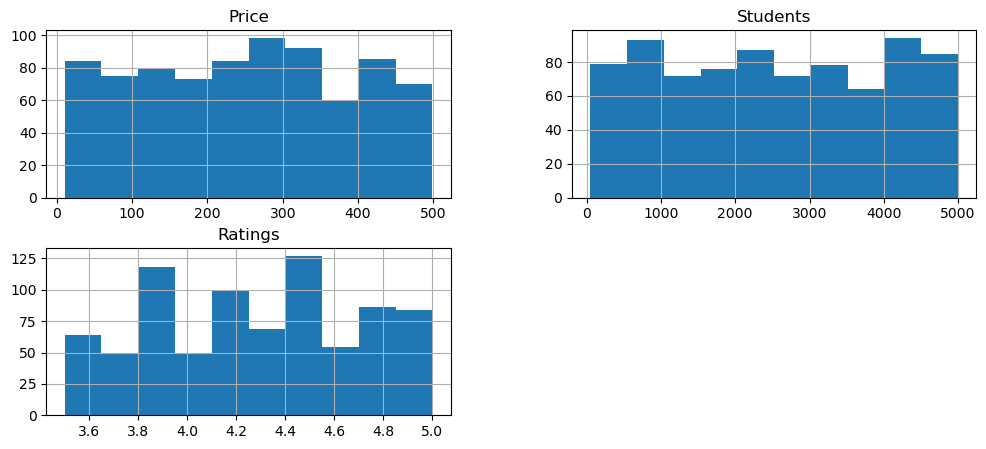

In [9]:
#First check the distribution of data

num_cols = ['Price', 'Students', 'Ratings']

df[num_cols].hist(figsize=(12,5))
plt.show() 

In [10]:
#Check skewness
print(df[num_cols].skew()) 

Price      -0.012163
Students    0.013813
Ratings     0.012696
dtype: float64


**Since data are approximately normally distributed we will use z-score method to detect outlier** 

In [14]:
# Numerical columns
num_cols = ['Price', 'Students', 'Ratings']

# Calculate z-scores
z_scores = np.abs(zscore(df[num_cols]))

# Threshold
threshold = 3

# Detect outliers
outliers = (z_scores > threshold)


print(outliers.sum()) 

0


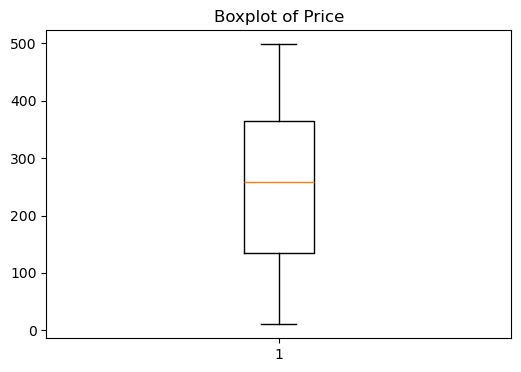

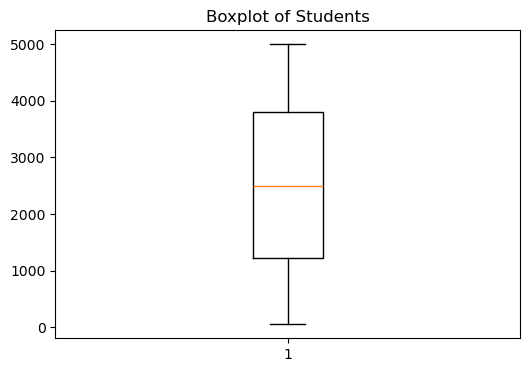

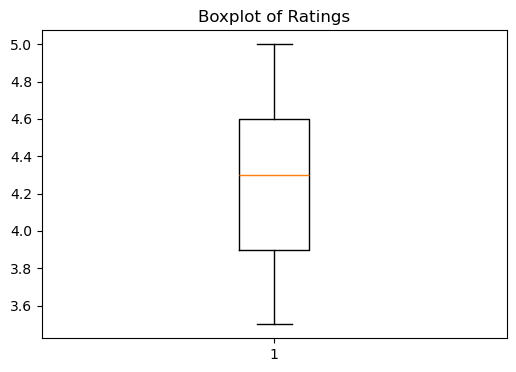

In [15]:
#Visually check outlier
num_cols = ['Price', 'Students', 'Ratings']

for col in num_cols:

    plt.figure(figsize=(6,4))

    plt.boxplot(df[col])

    plt.title(f'Boxplot of {col}')

    plt.show() 

**1. Check Brand Dominance** 

In [16]:
#Create Average rating and price per Brand

df["Students"] = pd.to_numeric(df["Students"], errors="coerce")
df["Rating"] = pd.to_numeric(df["Ratings"], errors="coerce")
df["Price"] = pd.to_numeric(df["Price"], errors="coerce") 
brand_summary = df.groupby("Brand_Name").agg(
    Total_Courses=("Course_ID", "count"),
    Total_Students=("Students", "sum"),
    
    Average_Rating=("Rating", "mean"),
    Average_Price=("Price", "mean")
).reset_index()

brand_summary  

,Brand_Name,Total_Courses,Total_Students,Average_Rating,Average_Price
0,Alpha,77,194710.0,4.336364,247.535221
1,Apex,76,200974.0,4.270526,264.211816
2,Centre of Excellence,72,192298.0,4.200556,227.400889
3,FutureLearn,87,230673.0,4.261149,262.126943
4,Global Edulink,84,210838.0,4.295952,245.305690
5,IMOH,81,203639.0,4.238519,239.494370
6,New Skills Academy,97,237302.0,4.230722,260.410144
7,NextGen,72,190382.0,4.292222,254.480444
8,Stonebridge College,100,223581.0,4.236200,262.271120
9,StudyHub,54,134956.0,4.282593,253.466704


In [17]:
#Create student market share to check the dominance of each brand
brand_summary["Student_Market_Share_%"] = (
    brand_summary["Total_Students"] / brand_summary["Total_Students"].sum()
) * 100

brand_summary 

,Brand_Name,Total_Courses,Total_Students,Average_Rating,Average_Price,Student_Market_Share_%
0,Alpha,77,194710.0,4.336364,247.535221,9.642197
1,Apex,76,200974.0,4.270526,264.211816,9.952396
2,Centre of Excellence,72,192298.0,4.200556,227.400889,9.522753
3,FutureLearn,87,230673.0,4.261149,262.126943,11.423114
4,Global Edulink,84,210838.0,4.295952,245.305690,10.440869
5,IMOH,81,203639.0,4.238519,239.494370,10.084369
6,New Skills Academy,97,237302.0,4.230722,260.410144,11.751388
7,NextGen,72,190382.0,4.292222,254.480444,9.427871
8,Stonebridge College,100,223581.0,4.236200,262.271120,11.071913
9,StudyHub,54,134956.0,4.282593,253.466704,6.683131


In [18]:
#sort in descending order
dominant_brands = brand_summary.sort_values(
    by="Total_Students", 
    ascending=False
)

dominant_brands 

,Brand_Name,Total_Courses,Total_Students,Average_Rating,Average_Price,Student_Market_Share_%
6,New Skills Academy,97,237302.0,4.230722,260.410144,11.751388
3,FutureLearn,87,230673.0,4.261149,262.126943,11.423114
8,Stonebridge College,100,223581.0,4.236200,262.271120,11.071913
4,Global Edulink,84,210838.0,4.295952,245.305690,10.440869
5,IMOH,81,203639.0,4.238519,239.494370,10.084369
1,Apex,76,200974.0,4.270526,264.211816,9.952396
0,Alpha,77,194710.0,4.336364,247.535221,9.642197
2,Centre of Excellence,72,192298.0,4.200556,227.400889,9.522753
7,NextGen,72,190382.0,4.292222,254.480444,9.427871
9,StudyHub,54,134956.0,4.282593,253.466704,6.683131


**2.Do expensive courses actually perform better?** 

In [19]:
#For this we will use spearmen correlation
price_students_corr = df["Price"].corr(df["Students"], method="spearman")

price_ratings_corr = df["Price"].corr(df["Ratings"], method="spearman")

print("Spearman correlation between Price and Students:", price_students_corr)
print("Spearman correlation between Price and Ratings:", price_ratings_corr) 

Spearman correlation between Price and Students: 0.010447439190111542
Spearman correlation between Price and Ratings: 0.02623208100813238


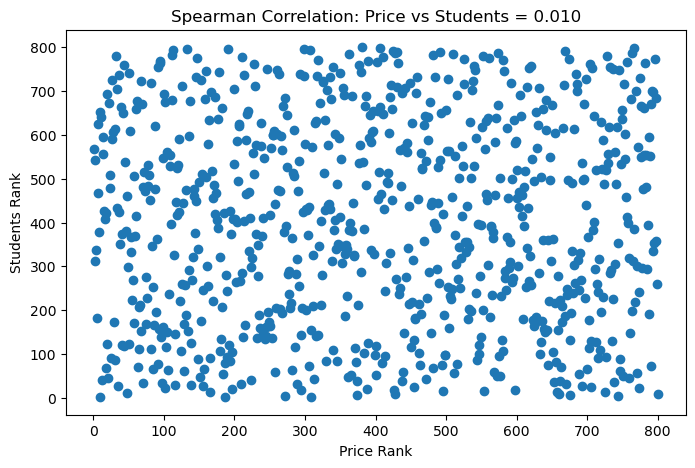

In [20]:
#Graphical Representation
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Price"].rank(),
    df["Students"].rank()
)

plt.title(f"Spearman Correlation: Price vs Students = {price_students_corr:.3f}")
plt.xlabel("Price Rank")
plt.ylabel("Students Rank")

plt.show() 

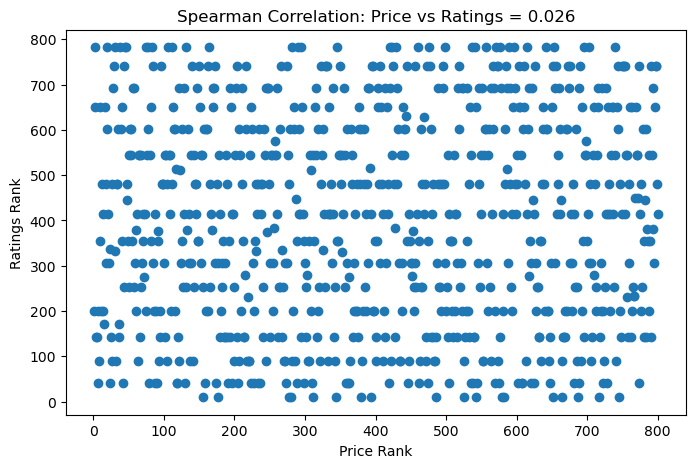

In [21]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["Price"].rank(),
    df["Ratings"].rank()
)

plt.title(f"Spearman Correlation: Price vs Ratings = {price_ratings_corr:.3f}")
plt.xlabel("Price Rank")
plt.ylabel("Ratings Rank")

plt.show() 

**3.Which brands appear overpriced relative to market trust?**

In [23]:
#Create brand level summary

brand_trust = df.groupby("Brand_Name").agg(
    Total_Courses=("Course_ID", "count"),
    Average_Price=("Price", "mean"),
    Total_Students=("Students", "sum"),
    Average_Students=("Students", "mean"),
    Average_Rating=("Ratings", "mean")
).reset_index()

brand_trust

,Brand_Name,Total_Courses,Average_Price,Total_Students,Average_Students,Average_Rating
0,Alpha,77,247.535221,194710.0,2528.701299,4.336364
1,Apex,76,264.211816,200974.0,2644.394737,4.270526
2,Centre of Excellence,72,227.400889,192298.0,2670.805556,4.200556
3,FutureLearn,87,262.126943,230673.0,2651.413793,4.261149
4,Global Edulink,84,245.305690,210838.0,2509.976190,4.295952
5,IMOH,81,239.494370,203639.0,2514.061728,4.238519
6,New Skills Academy,97,260.410144,237302.0,2446.412371,4.230722
7,NextGen,72,254.480444,190382.0,2644.194444,4.292222
8,Stonebridge College,100,262.271120,223581.0,2235.810000,4.236200
9,StudyHub,54,253.466704,134956.0,2499.185185,4.282593


In [24]:
#Create market benchmark
market_avg_price = brand_trust["Average_Price"].mean()
market_avg_students = brand_trust["Average_Students"].mean()
market_avg_rating = brand_trust["Average_Rating"].mean()

print("Market Average Price:", market_avg_price)
print("Market Average Students:", market_avg_students)
print("Market Average Rating:", market_avg_rating) 

Market Average Price: 251.6703341310925
Market Average Students: 2534.4955303837314
Market Average Rating: 4.264480229676627


In [25]:
#Find overpriced brands
overpriced_brands = brand_trust[
    (brand_trust["Average_Price"] > market_avg_price) &
    (brand_trust["Average_Students"] < market_avg_students) &
    (brand_trust["Average_Rating"] <= market_avg_rating)
].sort_values("Average_Price", ascending=False)

overpriced_brands 

,Brand_Name,Total_Courses,Average_Price,Total_Students,Average_Students,Average_Rating
8,Stonebridge College,100,262.271120,223581.0,2235.810000,4.236200
6,New Skills Academy,97,260.410144,237302.0,2446.412371,4.230722
